# Градиентный бустинг (Gradient Boosting)

**Ключевое отличие от бэггинга:**

- Бэггинг: деревья обучаются **параллельно**, независимо друг от друга, предсказания усредняются
- Бустинг: деревья обучаются **последовательно**, каждое следующее **исправляет ошибки** предыдущего

Каждое новое дерево обучается не на исходных метках y, а на **остатках**  на том, что предыдущий ансамбль предсказал неправильно.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

np.random.seed(42)

## 1. Загрузка данных

In [5]:
wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Трейн: {X_train.shape}, Тест: {X_test.shape}")

Трейн: (133, 13), Тест: (45, 13)


## 2. Идея бустинга на регрессии - наглядно

Проще всего понять бустинг на задаче регрессии.

**Шаг 1:** Предсказываем y первым деревом → получаем остатки (residuals = y_true - y_pred)

**Шаг 2:** Второе дерево обучается предсказывать **остатки**, а не y

**Шаг 3:** Итоговое предсказание = дерево_1 + lr × дерево_2 + lr × дерево_3 + ...

lr (learning_rate) — насколько доверяем каждому дереву. Маленький lr → нужно больше деревьев → лучше качество, но медленнее.

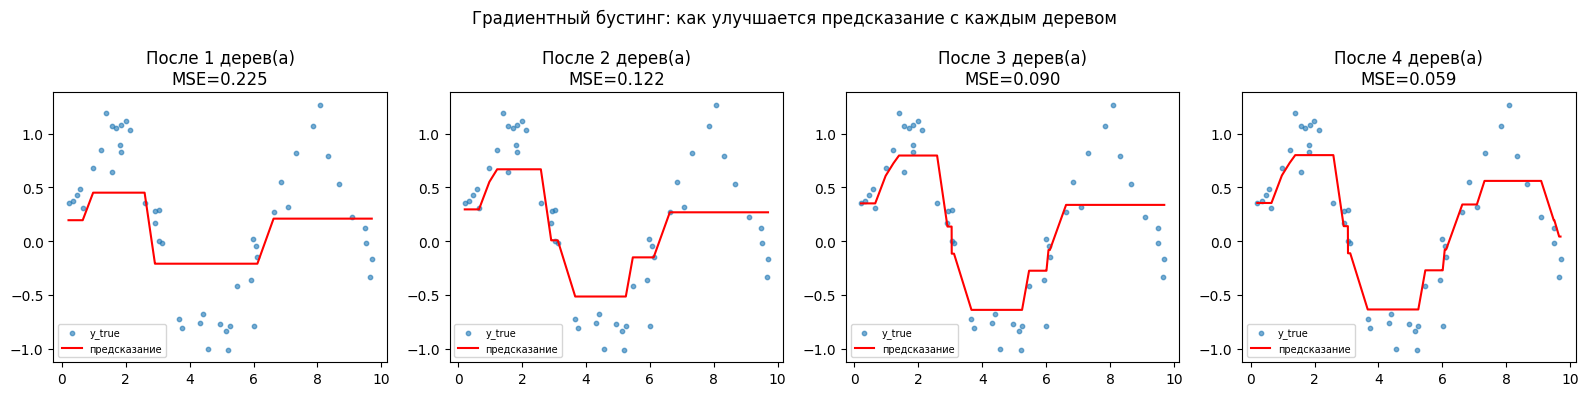

In [6]:
# Демонстрация на простых синтетических данных (регрессия)
np.random.seed(42)
X_simple = np.sort(np.random.uniform(0, 10, 50)).reshape(-1, 1)
y_simple = np.sin(X_simple).ravel() + np.random.normal(0, 0.2, 50)

lr = 0.5
n_steps = 4
trees_reg = []
residuals = y_simple.copy()
y_pred_cumulative = np.zeros(len(y_simple))

fig, axes = plt.subplots(1, n_steps, figsize=(16, 4))

for step in range(n_steps):
    # Обучаем дерево на текущих остатках
    tree = DecisionTreeRegressor(max_depth=2, random_state=step)
    tree.fit(X_simple, residuals)
    trees_reg.append(tree)

    # Обновляем предсказание
    y_pred_cumulative += lr * tree.predict(X_simple)

    # Считаем новые остатки
    residuals = y_simple - y_pred_cumulative

    ax = axes[step]
    ax.scatter(X_simple, y_simple, s=10, alpha=0.6, label='y_true')
    ax.plot(X_simple, y_pred_cumulative, color='red', label=f'предсказание')
    ax.set_title(f'После {step+1} дерев(а)\nMSE={np.mean(residuals**2):.3f}')
    ax.legend(fontsize=7)

plt.suptitle('Градиентный бустинг: как улучшается предсказание с каждым деревом')
plt.tight_layout()
plt.show()

## 3. Почему это называется «градиентным» бустингом?

Остатки (y_true - y_pred) - это **отрицательный градиент** функции потерь MSE по предсказаниям:

```
MSE = (1/n) × Σ(y - ŷ)²
∂MSE/∂ŷ = -2 × (y - ŷ) = -2 × остаток
```

Обучая дерево на остатках, мы делаем шаг **градиентного спуска** в пространстве предсказаний.  
Это и есть «градиентный» бустинг — бустинг обобщённый через градиентный спуск.

## 4. GradientBoostingClassifier из sklearn

In [7]:
gb = GradientBoostingClassifier(
    n_estimators=100,    # количество деревьев
    learning_rate=0.1,   # lr — насколько доверяем каждому дереву
    max_depth=3,         # глубина каждого дерева (обычно 3-5 для бустинга)
    subsample=0.8,       # доля объектов для каждого дерева (stochastic boosting)
    random_state=42
)

gb.fit(X_train, y_train)
print(f"GradientBoosting accuracy: {accuracy_score(y_test, gb.predict(X_test)):.3f}")
print()
print(classification_report(y_test, gb.predict(X_test), target_names=wine.target_names))

GradientBoosting accuracy: 0.978

              precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       1.00      0.94      0.97        18
     class_2       1.00      1.00      1.00        12

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## 5. XGBoost - оптимизированный градиентный бустинг

XGBoost (eXtreme Gradient Boosting) - это градиентный бустинг с:
- регуляризацией L1/L2 прямо в функции потерь (защита от переобучения)
- параллельным построением деревьев
- умной работой с пропусками

На практике XGBoost или LightGBM используются вместо sklearn GradientBoosting - они быстрее и точнее.

In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
print(f"XGBoost accuracy: {accuracy_score(y_test, xgb_model.predict(X_test)):.3f}")

d:\anaconda3\envs\ml-labs\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:48:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost accuracy: 1.000


## 6. Влияние learning_rate и n_estimators

Ключевой компромисс: меньший lr требует больше деревьев, но даёт лучшее качество.  
lr и n_estimators всегда подбираются вместе.

In [ ]:
configs = [
    {'learning_rate': 0.5,  'n_estimators': 20},
    {'learning_rate': 0.1,  'n_estimators': 100},
    {'learning_rate': 0.05, 'n_estimators': 200},
    {'learning_rate': 0.01, 'n_estimators': 500},
]

print(f"{'lr':>6} | {'n_est':>6} | {'CV accuracy':>12}")
print("-" * 30)
for cfg in configs:
    model = GradientBoostingClassifier(**cfg, random_state=42)
    score = cross_val_score(model, X, y, cv=5).mean()
    print(f"{cfg['learning_rate']:>6} | {cfg['n_estimators']:>6} | {score:>12.3f}")

    lr |  n_est |  CV accuracy
------------------------------
   0.5 |     20 |        0.944
   0.1 |    100 |        0.939
  0.05 |    200 |        0.939


## 7. Сравнение всех методов

In [ ]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

models = {
    'Decision Tree':         DecisionTreeClassifier(random_state=42),
    'Bagging':               BaggingClassifier(n_estimators=100, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':               xgb.XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42),
}

print(f"{'Модель':<25} | {'Test Accuracy':>13} | {'CV Accuracy (5-fold)':>20}")
print("-" * 65)
for name, model in models.items():
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_acc = cross_val_score(model, X, y, cv=5).mean()
    print(f"{name:<25} | {test_acc:>13.3f} | {cv_acc:>20.3f}")